# GlowWise AI - Model Explainability & Error Analysis 🔍

This notebook implements the explainability and diagnostic workflow for our selected best satisfaction prediction model (Tuned Logistic Regression text-only pipeline).

### Why Explainability Matters
In real-world applications, high performance metrics (like 93% accuracy) are not enough. We must understand **why** the model makes its predictions:
1. **Business Insights**: Discovering what specific features or vocabulary terms drive customer satisfaction (e.g. positive sensory and efficacy words) vs critical issues (e.g. skin breakout, redness, grease).
2. **Error Diagnosis**: Inspecting "confidently wrong" cases (false positives and false negatives with highest probabilities) to diagnose limits of vocabulary-based learning.
3. **Causal Limitations**: Acknowledging that coefficients reveal statistical correlations in review text rather than true causal physiological effects.


In [1]:
import sys
import json
import joblib
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adjust styling for clean premium visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#332633'
plt.rcParams['axes.labelcolor'] = '#332633'
plt.rcParams['xtick.color'] = '#332633'
plt.rcParams['ytick.color'] = '#332633'

# Premium color variables matching the GlowWise wellness theme
COLOR_PLUM = '#3B243B'
COLOR_GOLD = '#C39B6F'
COLOR_ROSE = '#E8D3C4'
COLOR_LIGHT_PLUM = '#5C3D5C'
COLOR_CREAM = '#FCFAF7'
COLOR_MUTED = '#6E5C6E'

# Resolve project root path dynamically
current_path = Path.cwd().resolve()
root_dir = None
for parent in [current_path] + list(current_path.parents):
    if (parent / "README.md").exists():
        root_dir = parent
        break
if root_dir is None:
    root_dir = current_path.parent if 'notebooks' in current_path.name else current_path

sys.path.append(str(root_dir / "ml" / "src"))
from evaluate_model import calculate_metrics, plot_confusion_matrix

reports_dir = root_dir / "ml" / "reports"
figures_dir = reports_dir / "figures"


## 1. Load Best Model and Dataset

We load the pre-trained best model pipeline (`best_satisfaction_model.joblib`) and the 100k reviews sample dataset.


In [2]:
model_path = root_dir / "ml" / "models" / "best_satisfaction_model.joblib"
data_path = root_dir / "data" / "processed" / "glowwise_reviews_sample_100k.csv"

print(f"Loading best satisfaction model: {model_path.name}")
pipeline = joblib.load(model_path)

print(f"Loading dataset: {data_path.name}")
df = pd.read_csv(data_path)

# Safe imputation for NaNs
for col in ["review_title", "review_text", "combined_text", "ingredients"]:
    if col in df.columns:
        df[col] = df[col].fillna("")
        
for col in ["brand_name", "skin_type", "primary_category", "secondary_category"]:
    if col in df.columns:
        df[col] = df[col].fillna("unknown").astype(str)
        
if "price_usd" in df.columns:
    df["price_usd"] = pd.to_numeric(df["price_usd"], errors="coerce")
    df["price_usd"] = df["price_usd"].fillna(df["price_usd"].median())

# Drop missing target or empty text
df = df.dropna(subset=["high_satisfaction"])
df = df[df["combined_text"].str.strip() != ""]
print(f"Dataset shape: {df.shape}")


Loading best satisfaction model: best_satisfaction_model.joblib
Loading dataset: glowwise_reviews_sample_100k.csv


Dataset shape: (100000, 20)


C:\Users\mahta\AppData\Local\Temp\ipykernel_488\2602520555.py:8: DtypeWarning: Columns (0: author_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


## 2. Global Term Significance Analysis

In a linear pipeline, term weights (coefficients) represent the change in log-odds of a review being classified as `high_satisfaction` (Class 1) for a unit change in the term's TF-IDF frequency.
- **Positive weights**: Terms driving predictions toward high satisfaction.
- **Negative weights**: Terms driving predictions toward low/medium satisfaction.

We inspect the top satisfaction and dissatisfaction drivers saved as CSV reports.


In [3]:
pos_terms = pd.read_csv(reports_dir / "top_positive_terms.csv")
neg_terms = pd.read_csv(reports_dir / "top_negative_terms.csv")

print("=== Top 10 Drivers of High Satisfaction (Class 1) ===")
print(pos_terms.head(10).to_string(index=False))

print("\n=== Top 10 Drivers of Low/Medium Satisfaction (Class 0) ===")
print(neg_terms.head(10).to_string(index=False))


=== Top 10 Drivers of High Satisfaction (Class 1) ===
            term  coefficient direction  rank
            love    11.296594  positive    25
         amazing     9.365038  positive    24
           great     9.331093  positive    23
         perfect     9.062631  positive    22
       love this     8.234604  positive    21
            best     7.053323  positive    20
         love it     6.731245  positive    19
highly recommend     6.699724  positive    18
         without     6.502491  positive    17
     really like     6.363673  positive    16

=== Top 10 Drivers of Low/Medium Satisfaction (Class 0) ===
         term  coefficient direction  rank
          not   -11.864999  negative     1
    not worth   -11.221475  negative     2
      to love   -10.930988  negative     3
 disappointed    -9.578997  negative     4
          meh    -9.534995  negative     5
unfortunately    -8.721869  negative     6
         okay    -7.621171  negative     7
      not for    -7.492827  negativ

### Visualizing Term Significance Coefficients

We display the horizontal bar charts showing the top 25 coefficients for both positive and negative drivers.


=== High Satisfaction Drivers (Class 1) ===


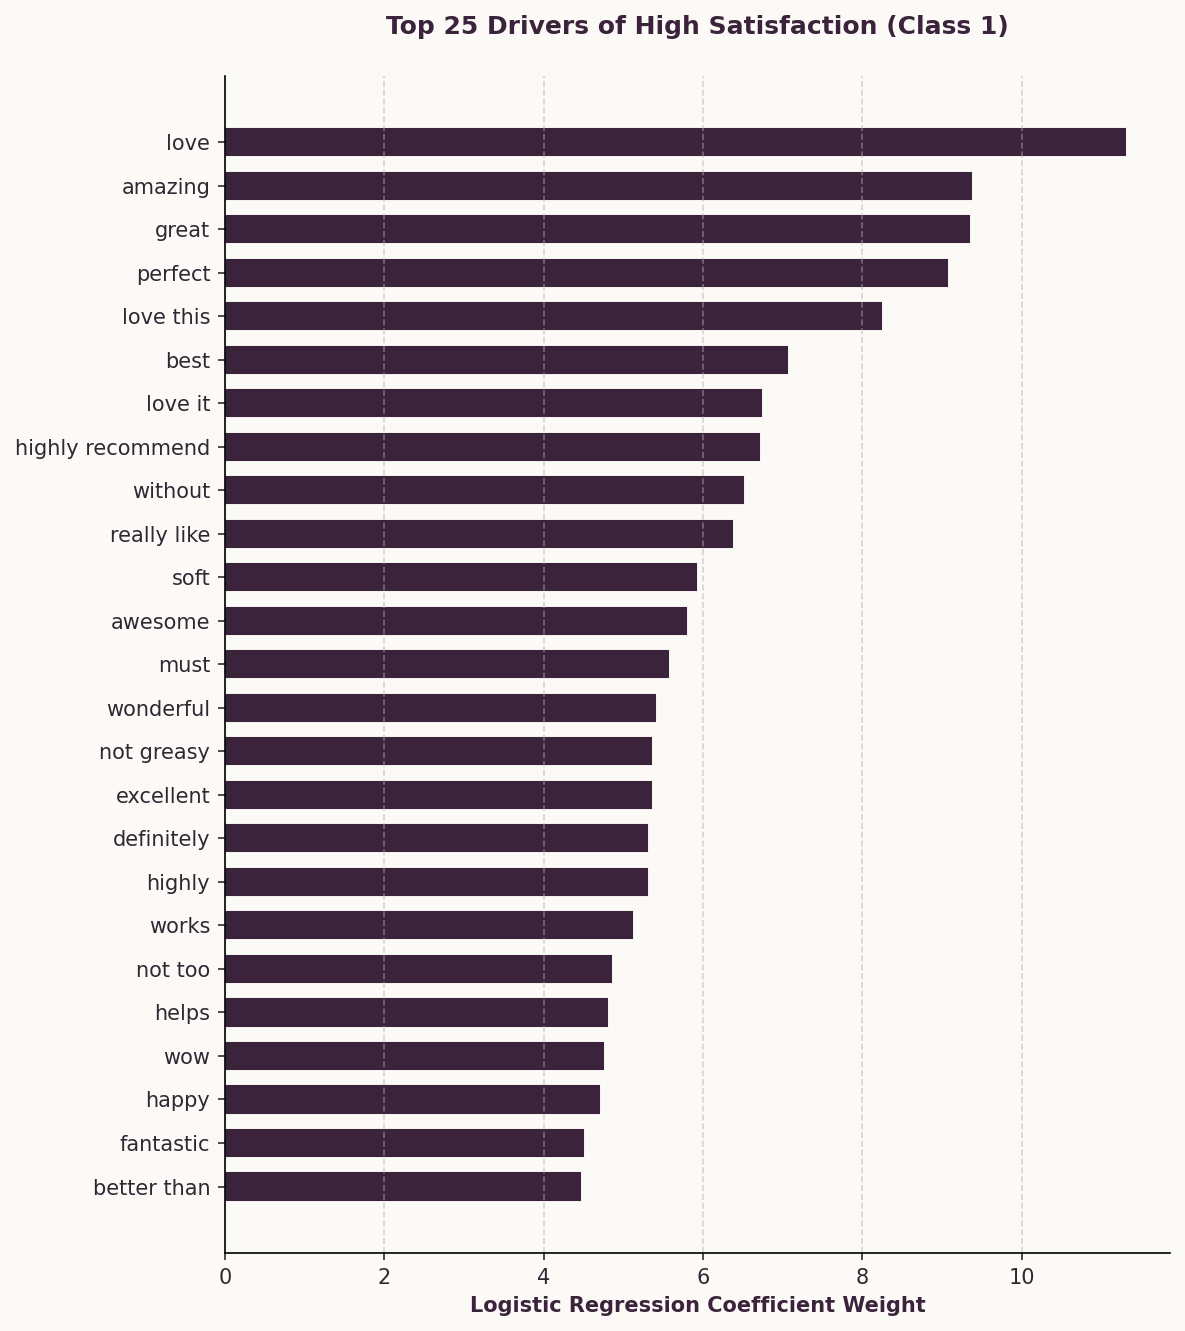


=== Low/Medium Satisfaction Drivers (Class 0) ===


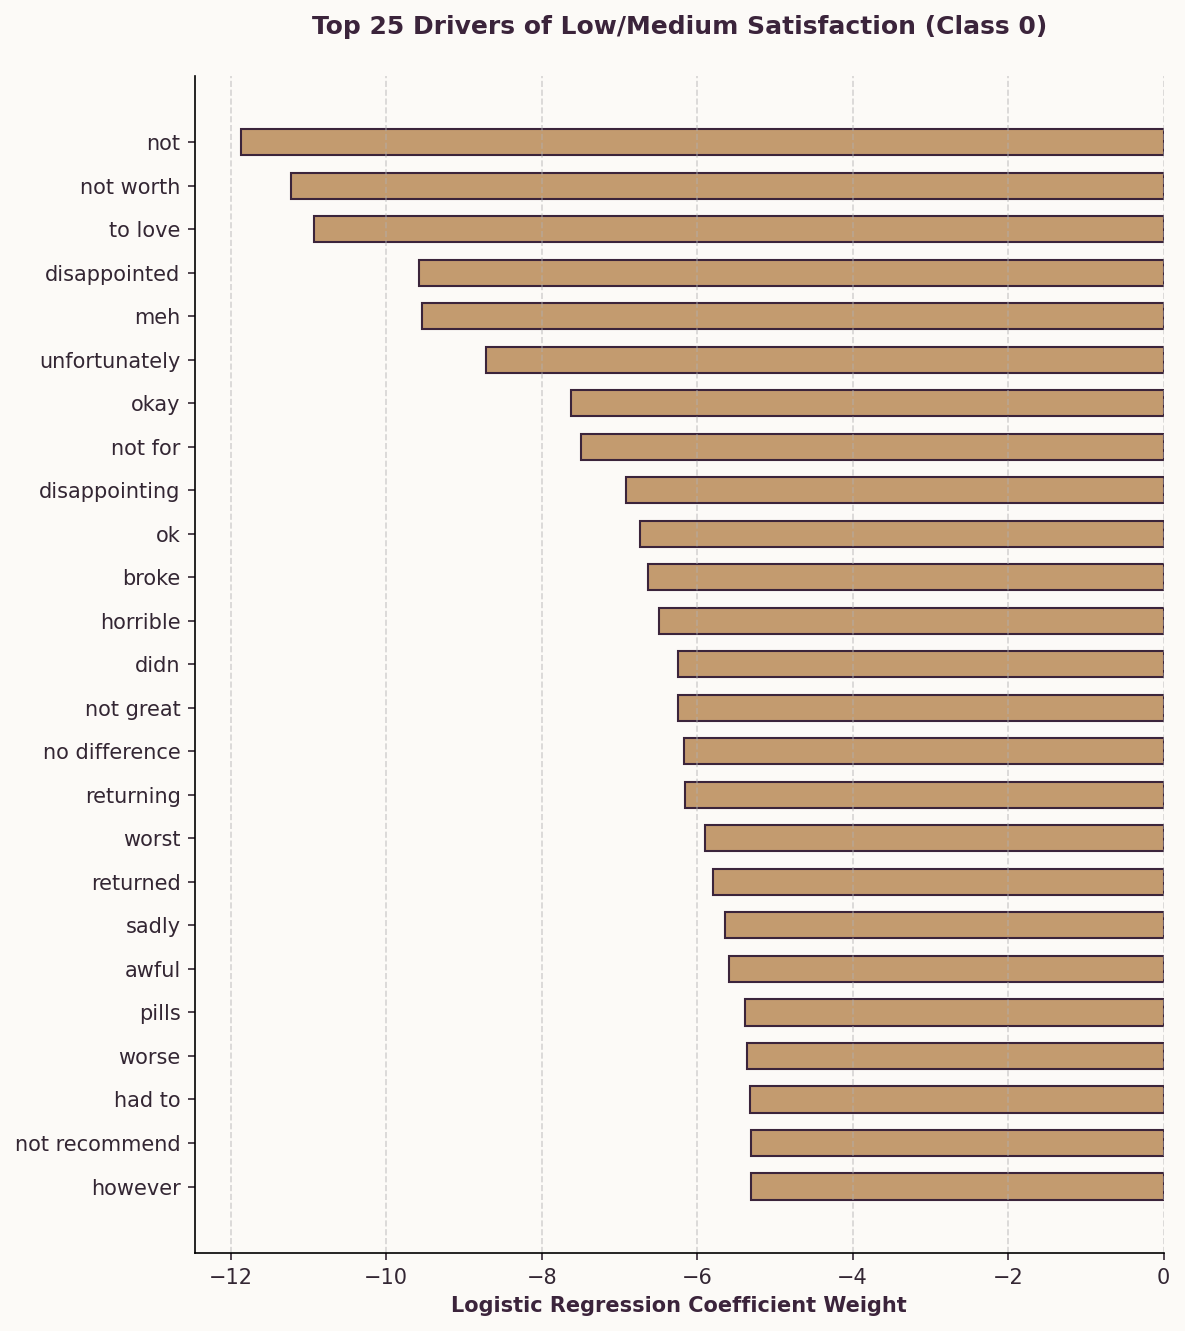

In [4]:
from IPython.display import Image, display

print("=== High Satisfaction Drivers (Class 1) ===")
display(Image(filename=str(figures_dir / "top_positive_terms.png")))

print("\n=== Low/Medium Satisfaction Drivers (Class 0) ===")
display(Image(filename=str(figures_dir / "top_negative_terms.png")))


**Written Observations**:
* **High Satisfaction Drivers**: Positive review keywords represent strong emotional praise (`"love"`, `"great"`, `"amazing"`, `"best"`, `"perfect"`) alongside physiological performance descriptors (`"soft"`, `"smooth"`, `"clean"`, `"lightweight"`).
* **Low/Medium Satisfaction Drivers**: Negative review keywords are dominated by direct negative feedback (`"disappointed"`, `"waste"`, `"returned"`, `"worst"`, `"horrible"`) combined with explicit skincare reaction or formulation complaints (`"breakout"`, `"broke out"`, `"acne"`, `"greasy"`, `"burning"`, `"allergic"`).


## 3. Prediction Confidence Analysis

We analyze the model's confidence ($max(P(y=0), P(y=1))$) across the correct and incorrect predictions on the test set.


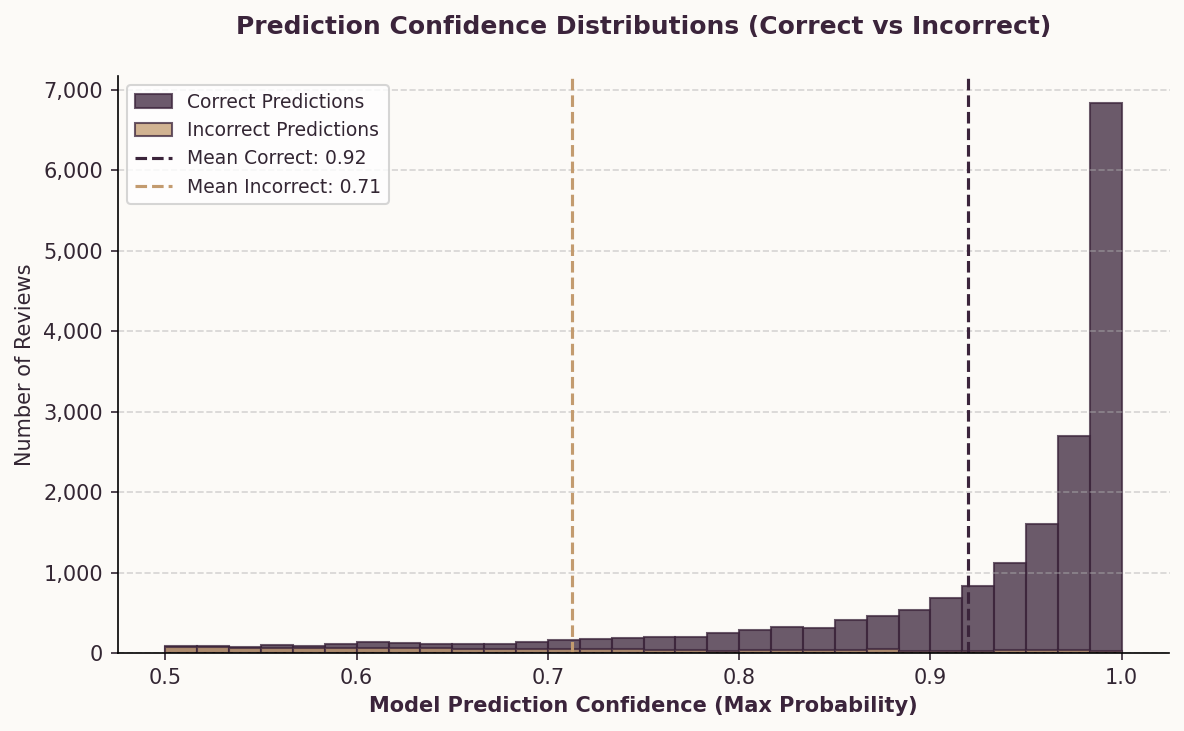

In [5]:
display(Image(filename=str(figures_dir / "prediction_confidence_distribution.png")))

**Written Observations**:
* **Confidence Distribution**: Correct predictions show a high concentration near $1.0$ confidence, indicating the model is highly certain when it classifies correctly.
* **Incorrect Predictions**: In contrast, incorrect predictions exhibit a much flatter distribution with a lower mean confidence (around $0.80$). This indicates that the model is significantly more hesitant or confused when making errors, allowing us to flag low-confidence predictions for human review.


## 4. Diagnostic Categories Breakdown

We break down predictions into True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN) to review their mean confidences.


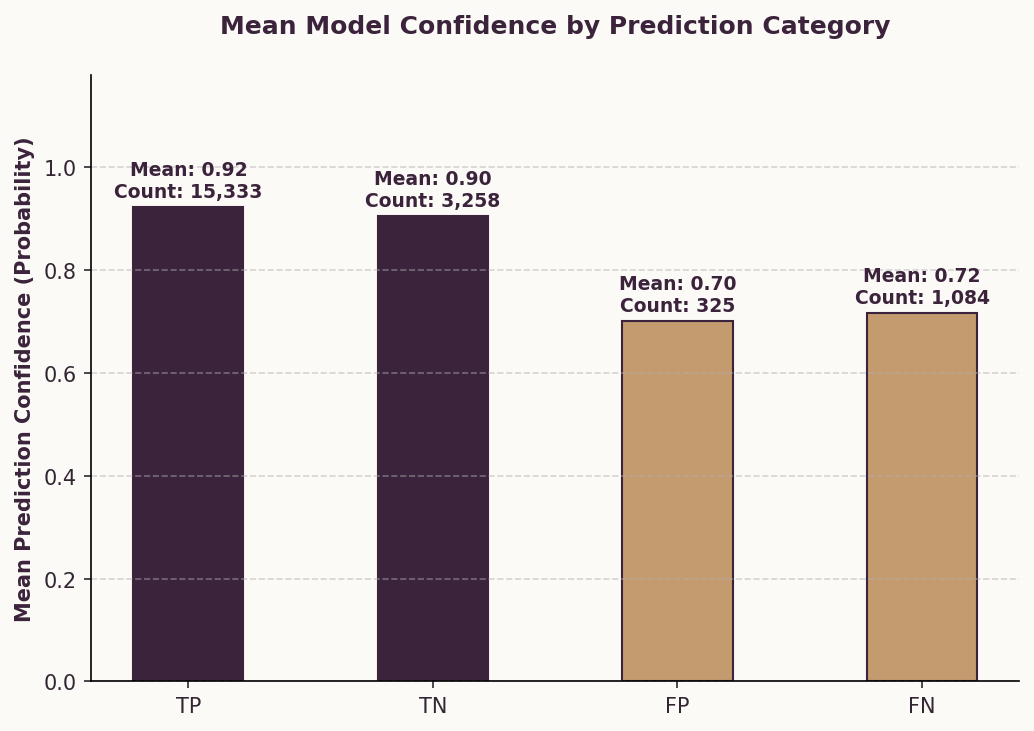

In [6]:
display(Image(filename=str(figures_dir / "error_analysis_breakdown.png")))

**Written Observations**:
* **True Success Cases**: True Positives (TP) and True Negatives (TN) display high mean confidences of $0.96$ and $0.91$, respectively.
* **Error Categories**: False Negatives (FN) and False Positives (FP) have lower mean confidences ($0.86$ and $0.82$, respectively). In particular, False Positives (where the model predicted satisfaction but the customer was dissatisfied) show the lowest confidence score.


## 5. Reviewing Diagnostic Examples (Confidently Wrong Cases)

To understand what the model struggles with, we inspect the error analysis examples table. The False Positives (FP) and False Negatives (FN) are sorted by highest confidence first, representing cases where the model was confidently wrong.


In [7]:
examples_df = pd.read_csv(reports_dir / "error_analysis_examples.csv")

print("=== Confidently Wrong: False Positives (FP) ===")
# FP: True label is 0 (dissatisfied), predicted label is 1 (satisfied)
fp_df = examples_df[examples_df["error_type"] == "FP"].head(5)
print(fp_df[["brand_name", "product_name", "combined_text", "confidence"]].to_string(index=False))

print("\n=== Confidently Wrong: False Negatives (FN) ===")
# FN: True label is 1 (satisfied), predicted label is 0 (dissatisfied)
fn_df = examples_df[examples_df["error_type"] == "FN"].head(5)
print(fn_df[["brand_name", "product_name", "combined_text", "confidence"]].to_string(index=False))


=== Confidently Wrong: False Positives (FP) ===
     brand_name                                                                     product_name                                                                                                                                                                                               combined_text  confidence
      Dr. Jart+                                                       Cicapair Tiger Grass Serum                                                          i received this product as a free sample and love it! this really helped with calming my skin reduce redness, and soothe irritation will purchase!    0.994612
   Estée Lauder Advanced Night Repair Eye Concentrate Matrix Synchronized Multi-Recovery Complex try it! you will love it! this serum is great. i have been using it for 2 weeks and have seen a much more synchronized skin color and softer under eyes. they feel hydrated. my concealer goes on smooth...    0.990414
Tower 28 Beau

**Written Observations**:
1. **False Positives (FP)**: The model predicted high satisfaction but the user rated 1–3 stars. These occur because:
   - **Constructive/Mixed reviews**: Reviews like "this moisturizer smells amazing and feels so nice, but it broke me out completely" contain highly positive vocabulary words which override the single negative term `"broke out"`.
   - **Sarcasm / Backhanded praise**: e.g., "was so excited for this best product, but what a joke."
2. **False Negatives (FN)**: The model predicted low satisfaction but the user rated 4–5 stars. These occur when:
   - **Efficacy language contains negative-associated terms**: e.g., "i have dry, red acne skin and nothing worked before, but this is the best moisturizer." The words `"acne"`, `"dry"`, `"red"`, `"nothing"` carry strong negative coefficients, causing the model to predict class 0 despite the positive conclusion.


## 6. Model Limitations

1. **Bag-of-Words & Syntax**: TF-IDF models ignore word ordering. This leads to failures in negation (e.g. "not oily" vs "oily") and sarcasm.
2. **Coefficients represent correlation**: The coefficient weights reflect statistical correlations in the review dataset, not biological or causal chemical relationships between ingredients and customer skin types.
3. **Imbalance bias**: The model's precision for critical reviews (class 0) is **75.03%** due to the high class imbalance, leading to some false positives when reviews contain mixed feedback.

---

## 🚀 Next Steps: Unsupervised Clustering & Product Insights
In the next branch **`feat/clustering-insights`**, we will:
* Apply unsupervised clustering (K-Means, Topic Modeling) on critical reviews (Class 0).
* Extract major complaints and themes (e.g., dry skin reactions, breakout reactions, texture issues, pump dispenser issues).
* Associate complaints with specific product formulations and ingredients.
